# 03 — Analyse Exploratoire des Données (EDA)

Ce notebook explore en profondeur le dataset nettoyé pour mettre en 
évidence les relations entre les variables.

**Objectifs :**
- Visualiser la distribution des variables
- Analyser les corrélations entre variables
- Explorer l'impact de chaque facteur sur la santé mentale
- Identifier les variables les plus pertinentes pour le modèle ML

**Dataset :** `data/processed/mental_health_cleaned.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# On se place à la racine du projet
os.chdir("..")

# Style global pour tous les graphiques matplotlib/seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Chargement du dataset nettoyé
data_path = os.path.join("data", "processed", "mental_health_cleaned.csv")
df = pd.read_csv(data_path)

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dataset chargé : 2405 lignes, 12 colonnes


=== DISTRIBUTION DE LA VARIABLE CIBLE ===



,Nombre,Pourcentage (%)
Mental Health Condition,,
Anxiety,628,26.11
PTSD,624,25.95
Depression,580,24.12
Bipolar,573,23.83


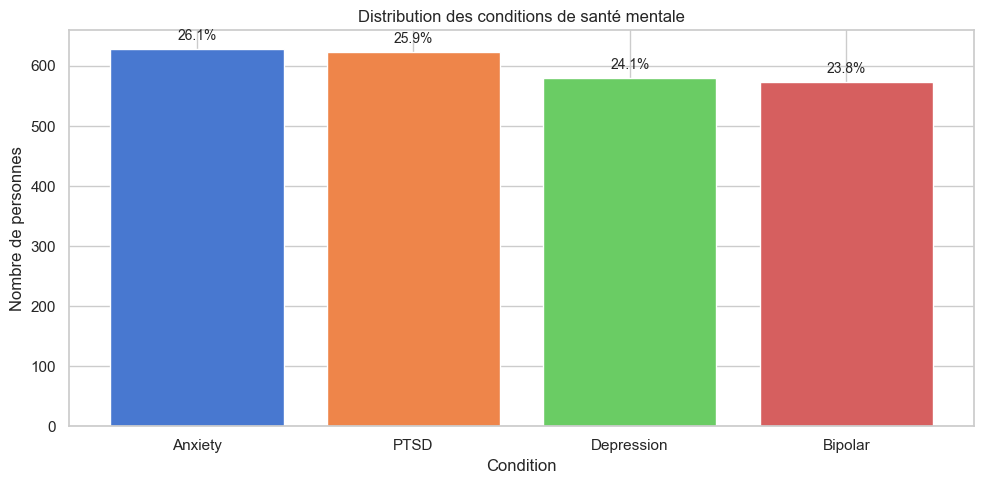

In [2]:
print("=== DISTRIBUTION DE LA VARIABLE CIBLE ===\n")

# Comptage et pourcentage par condition
target_counts = df["Mental Health Condition"].value_counts()
target_pct = df["Mental Health Condition"].value_counts(normalize=True) * 100

# Tableau récapitulatif
target_df = pd.DataFrame({
    "Nombre" : target_counts,
    "Pourcentage (%)" : target_pct.round(2)
})
display(target_df)

# Graphique
fig, ax = plt.subplots()
bars = ax.bar(target_counts.index, target_counts.values, 
              color=sns.color_palette("muted", len(target_counts)))

# Ajout des pourcentages au-dessus des barres
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("Distribution des conditions de santé mentale")
ax.set_xlabel("Condition")
ax.set_ylabel("Nombre de personnes")
plt.tight_layout()
plt.show()

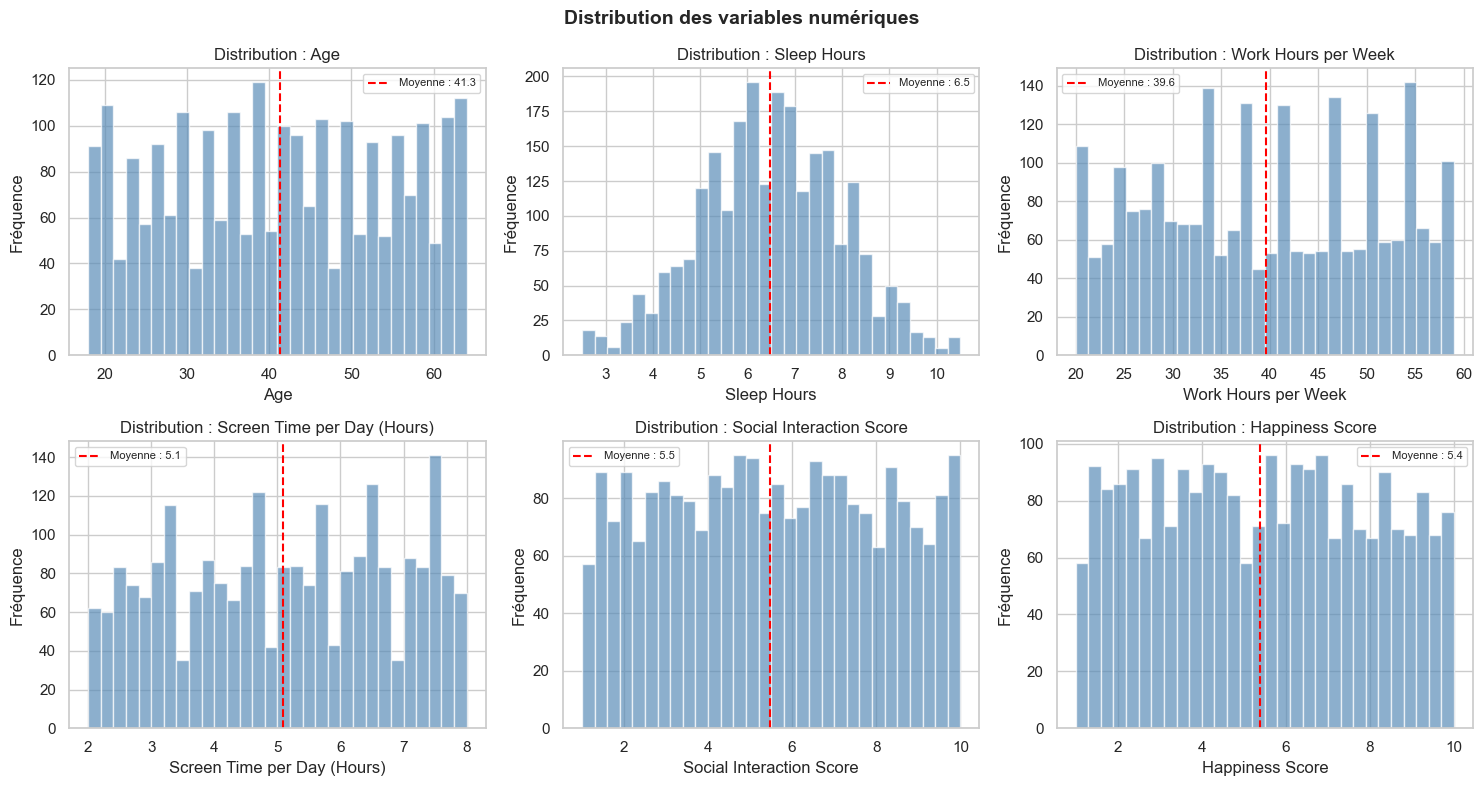

In [3]:
# Colonnes numériques
numerical_cols = ["Age", "Sleep Hours", "Work Hours per Week",
                  "Screen Time per Day (Hours)",
                  "Social Interaction Score", "Happiness Score"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()  # On aplatit pour itérer facilement

for i, col in enumerate(numerical_cols):
    # Histogramme + courbe de densité (KDE)
    axes[i].hist(df[col], bins=30, color="#5B8DB8", alpha=0.7, edgecolor="white")
    axes[i].set_title(f"Distribution : {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")
    
    # Ligne verticale pour la moyenne
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", 
                    linewidth=1.5, label=f"Moyenne : {df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution des variables numériques", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

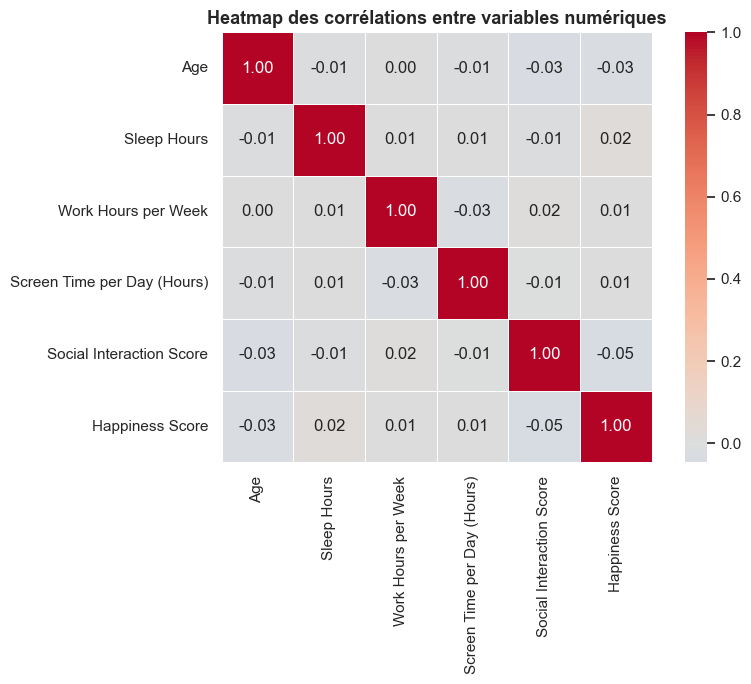

In [4]:
# Calcul de la matrice de corrélation
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

# Heatmap avec annotations des valeurs
sns.heatmap(
    corr_matrix,
    annot=True,          # Afficher les valeurs numériques
    fmt=".2f",           # Format à 2 décimales
    cmap="coolwarm",     # Rouge = corrélation positive, Bleu = négative
    center=0,            # Centre de la colormap à 0
    square=True,         # Cellules carrées
    linewidths=0.5,      # Séparation entre cellules
    ax=ax
)

ax.set_title("Heatmap des corrélations entre variables numériques", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_29776\482848460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_29776\482848460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_29776\482848460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_29776\482848460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

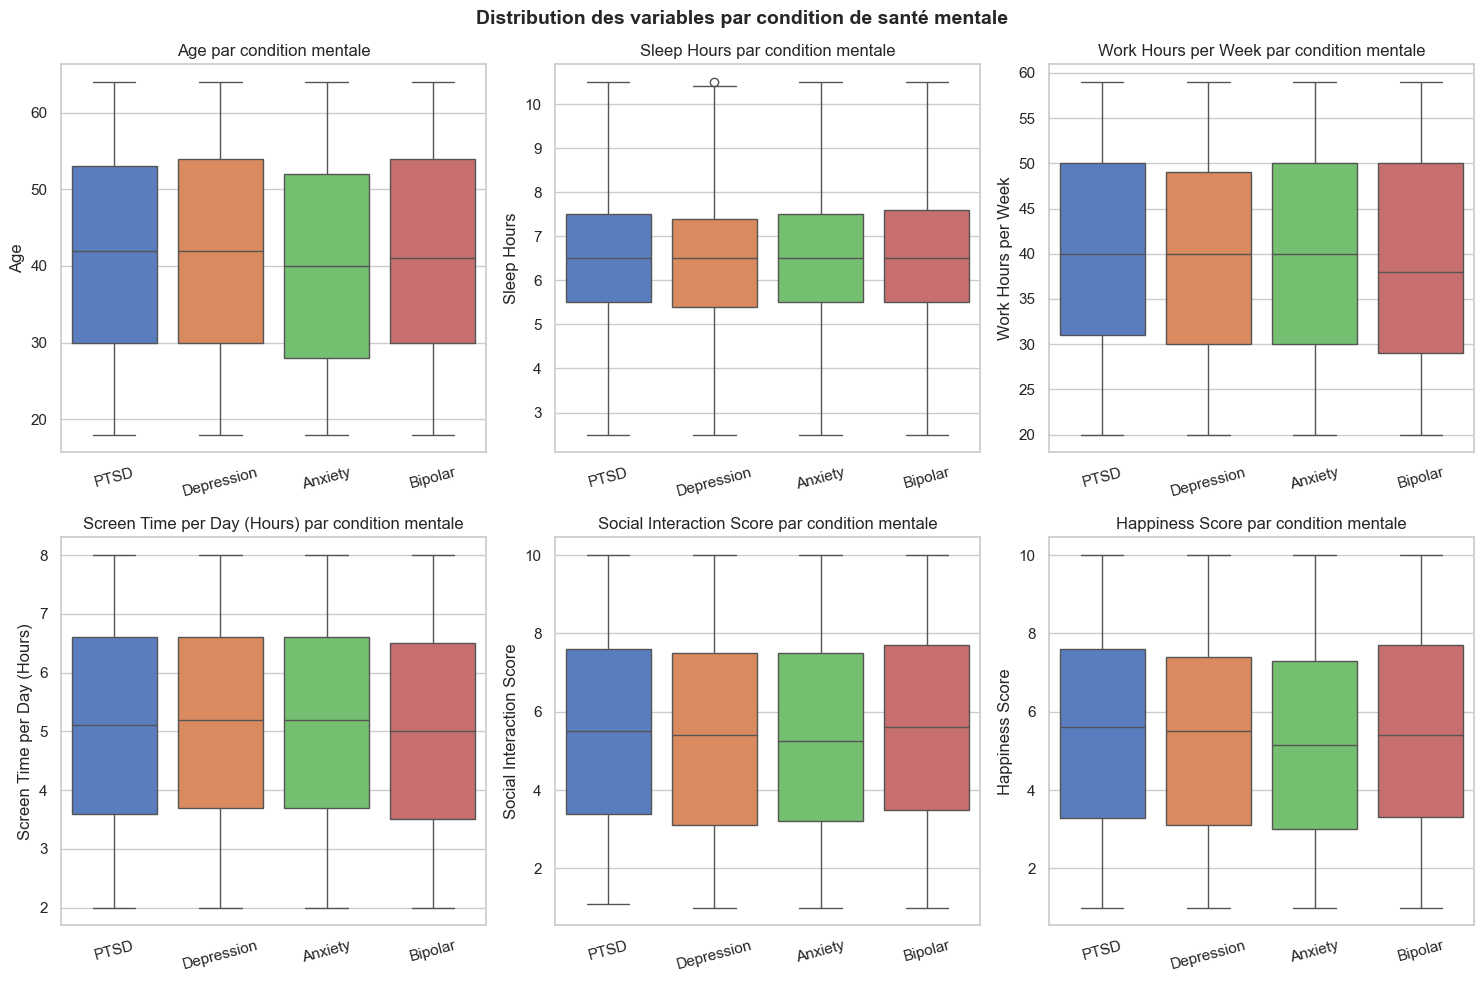

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        x="Mental Health Condition",
        y=col,
        palette="muted",
        ax=axes[i]
    )
    axes[i].set_title(f"{col} par condition mentale")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Distribution des variables par condition de santé mentale",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
# Moyenne des heures de sommeil par condition mentale
sleep_by_condition = df.groupby("Mental Health Condition")["Sleep Hours"].mean().sort_values()

fig = px.bar(
    x=sleep_by_condition.index,
    y=sleep_by_condition.values,
    labels={"x": "Condition de santé mentale", "y": "Heures de sommeil (moyenne)"},
    title="Moyenne des heures de sommeil par condition de santé mentale",
    color=sleep_by_condition.values,
    color_continuous_scale="Blues"
)
fig.update_layout(showlegend=False)
fig.show()

In [7]:
# Tableau croisé : Stress Level vs Mental Health Condition
stress_cross = pd.crosstab(
    df["Mental Health Condition"],
    df["Stress Level"],
    normalize="index"  # Normalisation par ligne = pourcentages
) * 100

fig = px.bar(
    stress_cross,
    barmode="group",
    labels={"value": "Pourcentage (%)", "Mental Health Condition": "Condition"},
    title="Répartition du niveau de stress par condition de santé mentale",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

In [8]:
# Tableau croisé : Exercise Level vs Mental Health Condition
exercise_cross = pd.crosstab(
    df["Mental Health Condition"],
    df["Exercise Level"],
    normalize="index"
) * 100

fig = px.bar(
    exercise_cross,
    barmode="group",
    labels={"value": "Pourcentage (%)", "Mental Health Condition": "Condition"},
    title="Répartition du niveau d'exercice par condition de santé mentale",
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig.show()

In [9]:
fig = px.scatter(
    df,
    x="Sleep Hours",
    y="Happiness Score",
    color="Mental Health Condition",
    title="Relation entre heures de sommeil et score de bonheur",
    labels={
        "Sleep Hours": "Heures de sommeil",
        "Happiness Score": "Score de bonheur"
    },
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

## Conclusions de l'EDA

### Observations clés
- **Variable cible** : (`Mental health Condition`) La distribution équilibrée des classes nous permet d'entraîner le modèle sans biais de classe.
- **Graphique 2** :Les distributions uniformes suggèrent un dataset synthétique, nos conclusions sont des tendances illustratives plutôt que des résultats cliniques.
- **Graphique 3**L'absence de corrélation entre variables numériques est caractéristique d'un dataset synthétique. Nous nous attendons à ce que les variables catégorielles soient plus discriminantes.
- **Graphique 4**Les boxplots confirment l'absence de signal discriminant dans les variables numériques , le modèle devra exploiter les variables catégorielles.
- **Sommeil** : Bien que la littérature scientifique établisse un lien fort entre manque de sommeil et dépression, notre dataset synthétique ne reproduit pas cette tendance, ce qui souligne ses limites.
- **Stress** : Une légère surreprésentation du stress élevé chez les personnes dépressives est observable, mais insuffisante pour être un prédicteur fort.
- **Exercice** : L'Exercise Level est la variable catégorielle montrant le signal le plus discriminant, notamment pour la Depression, c'est un résultat cohérent avec la littérature.
- L'absence de clusters dans le scatter plot confirme que la classification sera difficile, les conditions ne sont pas linéairement séparables dans cet espace de features.

### Variables les plus prometteuses pour le modèle ML
- Les variables les plus prometteuses pour le ML seront : Exercise Level, Stress Level, Diet Type, Country et Gender : les variables catégorielles.
### Prochaine étape
- Modélisation ML (`04_ml_model.ipynb`)